In [2]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os

In [5]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

Saved trajectory.png


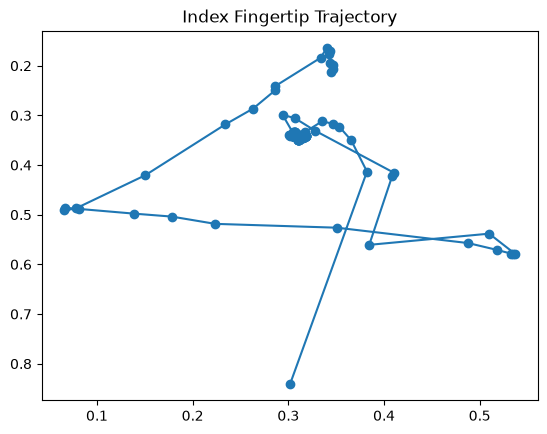

In [16]:
import math
import matplotlib.pyplot as plt
cap = cv2.VideoCapture(0)

trajectory = []

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        ret,frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(frame_rgb)

        mp_drawing.draw_landmarks(frame, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

        if results.right_hand_landmarks:
            lm = results.right_hand_landmarks.landmark
            wrist = lm[0]
            index_tip = lm[8]
            def is_finger_extended(landmarks, tip_id, pip_id):
                return landmarks[tip_id].y < landmarks[pip_id].y
            
            def landmark_distance(lm1, lm2):
                return math.sqrt((lm1.x - lm2.x) **2 +(lm1.y-lm2.y)**2)
            
            def extract_landmarks(results):
                def get_coords(landmark_list, num_points):
                    if landmark_list:
                        return np.array([[p.x, p.y, p.z] for p in landmark_list.landmark]).flatten()
                    return np.zeros(num_points * 3)
                pose = get_coords(results.pose_landmarks, 33)
                left_hand = get_coords(results.left_hand_landmarks, 21)
                right_hand = get_coords(results.right_hand_landmarks, 21)
                return np.concatenate([pose, left_hand, right_hand])
            
            trajectory.append((index_tip.x, index_tip.y))

        cv2.imshow("MediaPipe Practice",frame)

        key = cv2.waitKey(5) & 0xFF

        if key == ord("s"):
            vec = extract_landmarks(results)
            print(f"Saved vector of shape:{vec.shape}")
            np.save("sample_frame.npy", vec)
        
        if key == ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

if trajectory:
    xs, ys = zip(*trajectory)
    plt.plot(xs, ys, marker='o')
    plt.gca().invert_yaxis()
    plt.title("Index Fingertip Trajectory")
    plt.savefig("trajectory.png")
    print("Saved trajectory.png")
